<a href="https://colab.research.google.com/github/matheussfsp/mvp2/blob/main/MVP2_v6_credit_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Matheus dos Santos Figueroa Sanmartin Perie

Matrícula: 4052025000067

MVP2 - Machine Learning & Analytics

## 1. Escopo, objetivo e definição do problema
**Problema:** prever a **inadimplência** (default) do cliente no mês seguinte com base no histórico de pagamento e atributos socioeconômicos.

**Objetivo de negócio:** priorizar ações de retenção/cobrança e calibrar limites de crédito.

**Principais métricas:** ROC-AUC para comparação geral; PR-AUC e F1 para cenários desbalanceados; custos podem justificar _threshold tuning_.

Base Utilizada:
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients



## 2. Preparação do ambiente

In [1]:
!pip -q install ucimlrepo xgboost shap imbalanced-learn

import sys, platform, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import tempfile

# Seeds para reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

from ucimlrepo import fetch_ucirepo
from scipy.stats import randint, uniform

#foram incluidas pacotes e bibliotecas usados no desenvolvimento do notebook

### 2.2 Funções utilitárias (opcional)

In [2]:
from typing import Dict

def summarize_clf_metrics(y_true, y_proba, threshold=0.5) -> Dict[str, float]:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "f1@{:.2f}".format(threshold): float(f1_score(y_true, y_pred)),
    }

def plot_confusion(y_true, y_pred, labels=("No Default","Default")):
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=labels)
    disp.plot(values_format="d")
    plt.title("Matriz de Confusão")
    plt.show()

## 3. Dados: carga, entendimento e qualidade

In [3]:
ds = fetch_ucirepo(id=350)  # Dataset
X = ds.data.features
y = ds.data.targets
meta = ds.metadata
variables = ds.variables
print(X.shape)
print(y.shape)
display(X.head(3))
display(y.head(3))


(30000, 23)
(30000, 1)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000


,Y
0,1
1,1
2,0


### 3.1 Análise exploratória resumida (EDA)

In [4]:
# Tipos e valores ausentes
print(X.info())
print("\nValores ausentes por coluna (top 10):")
print(X.isna().sum().sort_values(ascending=False).head(10))

# Estatística descritiva
display(X.describe(include='all').T.head(20))

# Distribuição da classe
print("\nDistribuição do target:")
display(y.value_counts(normalize=True).rename("proporcao").to_frame())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0



Distribuição do target:


,proporcao
Y,
0,0.7788
1,0.2212


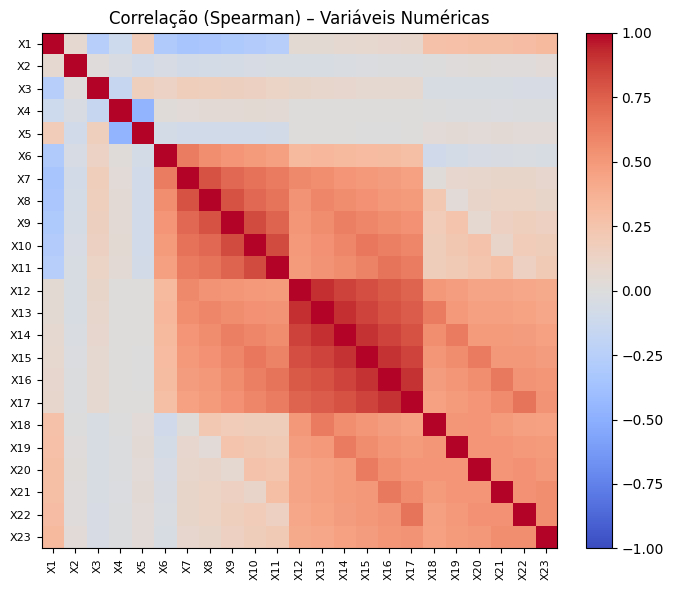

In [5]:
import numpy as np
import matplotlib.pyplot as plt

df = X.copy()

# Histograma + Boxplot de LIMIT_BAL
if "LIMIT_BAL" in df.columns:
    fig = plt.figure(figsize=(10,4))
    # histograma
    plt.subplot(1,2,1)
    plt.hist(df["LIMIT_BAL"], bins=40, color="steelblue", edgecolor="black")
    plt.xlabel("LIMIT_BAL"); plt.ylabel("Frequência"); plt.title("Distribuição do Limite de Crédito")
    # boxplot
    plt.subplot(1,2,2)
    plt.boxplot(df["LIMIT_BAL"], vert=True, showfliers=True)
    plt.ylabel("LIMIT_BAL"); plt.title("Boxplot de LIMIT_BAL")
    plt.tight_layout()
    plt.show()

# Barplot de EDUCATION
if "EDUCATION" in df.columns:
    counts = df["EDUCATION"].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    plt.bar(counts.index.astype(str), counts.values, color="darkorange", edgecolor="black")
    plt.xlabel("EDUCATION"); plt.ylabel("Contagem"); plt.title("Distribuição da Escolaridade")
    plt.tight_layout()
    plt.show()

# Boxplots (log10) para BILL_AMT1..6
bill_cols = [c for c in df.columns if c.upper().startswith("BILL_AMT")]
if bill_cols:
    sample = df[bill_cols].sample(min(5000, len(df)), random_state=42)
    data = [np.log10(np.clip(sample[c].replace(0, np.nan).dropna(), 1e-3, np.inf)) for c in sorted(bill_cols)]
    plt.figure(figsize=(10,5))
    plt.boxplot(data, vert=True, showfliers=False)
    plt.xticks(range(1, len(bill_cols)+1), sorted(bill_cols), rotation=30)
    plt.ylabel("log10(BILL_AMT)")
    plt.title("Distribuição de BILL_AMT* (escala log)")
    plt.tight_layout()
    plt.show()

# Correlação Spearman entre numéricas
num_all = df.select_dtypes(include=[np.number])
if not num_all.empty:
    corr = num_all.corr(method="spearman")
    plt.figure(figsize=(8,6))
    im = plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90, fontsize=8)
    plt.yticks(range(corr.shape[0]), corr.index, fontsize=8)
    plt.title("Correlação (Spearman) – Variáveis Numéricas")
    plt.tight_layout()
    plt.show()



### Comentários

A análise exploratória inicial traz algumas observações relevantes sobre o perfil da base de clientes e variáveis críticas para o problema de previsão de *default*:

1. **Distribuição do limite de crédito:**  
   O histograma e o boxplot revelam uma forte concentração de clientes em limites baixos (até $ 200 mil), poucos apresentam limites muito elevados (até $ 1 milhão).  
   

2. **Distribuição da escolaridade:**  
   A variável mostra predominância de clientes com nível de **graduação** e **ensino médio**, com menor representatividade em **pós-graduação**.  
   Esse fator educacional pode sugerir estudos futuros interessantes, tais como correlação entre endividamento e escolaridade.

3. **Valores de faturas:**  
   Os boxplots em escala log10 destacam forte **assimetria** e presença de **outliers extremos**.  
   A discrepância de valores demonstra a importância de fazer a padronização e trabalhar com logaritmos.

4. **Correlação entre variáveis numéricas:**  
   O heatmap de Spearman mostra **correlação elevada** entre as variáveis de fatura, como esperado, já que refletem valores mensais sucessivos.  


## 4. Definição do target, variáveis e divisão dos dados

In [6]:
print(type(y))

<class 'pandas.core.frame.DataFrame'>


In [7]:
# y como Series int
if isinstance(y, pd.DataFrame) and y.shape[1] == 1:
    y_colname = y.columns[0]
    y = y[y_colname].astype(int)
else:
    y = y.squeeze().astype(int)

# Renomear o Target - Y
y.name = "Default no próximo mês"
print("TARGET_Y:", y.name)

# Renomear atributos
rename_map = {
    "X1": "LIMIT_BAL", #limite
    "X2": "SEX", #genero 1m 2f
    "X3": "EDUCATION", #escolaridade
    "X4": "MARRIAGE", #estado civil
    "X5": "AGE", #idade
    "X6": "PAY_0", #status de pgt set/05 >1 -> atraso
    "X7": "PAY_2", #status ago/05
    "X8": "PAY_3", #status jul/05
    "X9": "PAY_4", #status jun/05
    "X10": "PAY_5", #status mai/05
    "X11": "PAY_6", #status abr/05
    "X12": "BILL_AMT1", #valor da fatura set/05
    "X13": "BILL_AMT2", #ago/05
    "X14": "BILL_AMT3",#jul/05
    "X15": "BILL_AMT4",#jun/05
    "X16": "BILL_AMT5",#mai/05
    "X17": "BILL_AMT6",#abr/05
    "X18": "PAY_AMT1",#valor pago set/05
    "X19": "PAY_AMT2",#ago/05
    "X20": "PAY_AMT3",#jul/05
    "X21": "PAY_AMT4",#jun/05
    "X22": "PAY_AMT5",#mai/05
    "X23": "PAY_AMT6",#abr/05
}
X = X.rename(columns=rename_map)

# Remover ID
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

# separar

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("Shapes:", X_train.shape, X_test.shape)

# selecionar as colunas categóricas e numéricas usando X_train
#    Categóricas: SEX, EDUCATION, MARRIAGE, PAY_0..PAY_6 (apenas status; NÃO inclui PAY_AMT*)
cat_like = [c for c in ["SEX","EDUCATION","MARRIAGE"] if c in X_train.columns]
cat_like += [c for c in X_train.columns if re.fullmatch(r"PAY_[0-6]", c.upper())]

num_like = [c for c in X_train.columns if c not in cat_like]

print("Categorias (heurística):", cat_like)
print("Numéricas (exemplo):", num_like[:10], "...")


TARGET_Y: Default no próximo mês
Shapes: (24000, 23) (6000, 23)
Categorias (heurística): ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numéricas (exemplo): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2'] ...


In [8]:
#verificar se y de fato foi convertido para Series e X Dataframe
print(type(y))
print(type(X))

display(X.head(5))
display(y.head(5))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


,Default no próximo mês
0,1
1,1
2,0
3,0
4,0


## 5. Tratamento de dados e **Pipeline** de pré-processamento

In [9]:
#variáveis numericas -> usar mediana
numeric_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])
#variáveis categoricas usar mais frente - moda.
categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=True,dtype=np.float32)),
])

preprocess = ColumnTransformer(sparse_threshold=0.3, transformers=[
    ("num", numeric_transform, num_like),
    ("cat", categorical_transform, cat_like),
])
preprocess


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler',
                                                  StandardScaler(with_mean=False))]),
                                 ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
                                  'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
                                  'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                                  'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
                                  'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(dtype=<class 'numpy.float32'>,
                                                                handle_unknown='ignore'))]),
                                 ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0',
                                  'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                                  'PAY_6'])])

## 6. Baseline e modelos candidatos

In [10]:
#criar modelos comparativos
# A Regressão Logística é utilizada pela facilidade de interpretação e ampla adoção regulatória em sistemas de crédito.
# O Random Forest representa um ensemble baseado em bagging, capaz de capturar interações não lineares entre variáveis e reconhecido como benchmark em estudos comparativos fornecendo robustez adicional frente a overfitting.
#Já o XGBoost é frequentemente reportado como superior em métricas como ROC-AUC e PR-AUC em bases desbalanceadas, embora à custa de maior complexidade interpretativa.


models = {
    "log_reg": LogisticRegression(max_iter=1000, n_jobs=None, class_weight="balanced"),
    "rf": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=SEED, n_jobs=-1, class_weight="balanced_subsample"
    ),
    "xgb": XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=SEED, eval_metric="logloss", tree_method="hist"
    ),
}
models


{'log_reg': LogisticRegression(class_weight='balanced', max_iter=1000),
 'rf': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                        n_jobs=-1, random_state=42),
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=400, n_jobs=None,
               num_parallel_tree=None, ...

### 6.1 Treino e avaliação rápida (baseline vs candidatos)

In [11]:
_cachedir = tempfile.mkdtemp()
def make_pipe(clf):
    return Pipeline([("preprocess", preprocess), ("clf", clf)], memory=_cachedir)

safe_models = {}
for name, clf in models.items():
    if hasattr(clf, "n_jobs"): clf.set_params(n_jobs=1)
    if hasattr(clf, "nthread"): clf.set_params(nthread=1)
    safe_models[name] = clf

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {"roc_auc":"roc_auc", "pr_auc":"average_precision", "f1":"f1"}

rows = []
for name, clf in safe_models.items():
    pipe = make_pipe(clf)
    cvres = cross_validate(pipe, X_train, y_train,
                           cv=cv, scoring=scoring,
                           n_jobs=2, return_train_score=False)
    rows.append({
        "modelo": name,
        "roc_auc": float(np.mean(cvres["test_roc_auc"])),
        "pr_auc": float(np.mean(cvres["test_pr_auc"])),
        "f1": float(np.mean(cvres["test_f1"])),
        "tempo_s": float(np.sum(cvres["fit_time"]) + np.sum(cvres["score_time"])),
        "n_folds": cv.get_n_splits(),
    })

res_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(res_df)

,modelo,roc_auc,pr_auc,f1,tempo_s,n_folds
0,xgb,0.774490,0.547985,0.478441,18.014736,3
1,rf,0.771436,0.537185,0.450262,322.666313,3
2,log_reg,0.768839,0.541567,0.533822,5.514462,3


## 7. Validação e Otimização de Hiperparâmetros - seguir aqui


In [12]:
#usando o XGB - melhores resultados
xgb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=1
    ))
])


param_distributions = {
    "clf__n_estimators":      randint(300, 800),
    "clf__max_depth":         randint(3, 9),
    "clf__learning_rate":     uniform(0.02, 0.10),
    "clf__subsample":         uniform(0.7, 0.3),
    "clf__colsample_bytree":  uniform(0.6, 0.4),
    "clf__min_child_weight":  randint(1, 8),
    "clf__reg_lambda":        uniform(0.0, 2.0),
    "clf__gamma":             uniform(0.0, 2.0),
}


scoring = {
    "roc_auc": "roc_auc",
    "pr_auc":  "average_precision",
    "f1":      "f1",
}

search_xgb = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_distributions,
    n_iter=5,
    cv=2,
    scoring=scoring,
    refit="roc_auc",
    n_jobs=2,
    random_state=SEED,
    verbose=1,
    pre_dispatch="2*n_jobs",
    error_score="raise",
)

search_xgb.fit(X_train, y_train)

print("Selecionado/Refit por:", search_xgb.refit)
print("Melhor ROC-AUC (CV):", search_xgb.best_score_)
print("Melhores Params:", search_xgb.best_params_)

cvres_xgb = pd.DataFrame(search_xgb.cv_results_)
best_row_xgb = cvres_xgb.iloc[search_xgb.best_index_]
print("PR-AUC (CV) do melhor-por-ROC:", best_row_xgb["mean_test_pr_auc"])
print("F1 (CV) do melhor-por-ROC:",     best_row_xgb["mean_test_f1"])

best_model = search_xgb.best_estimator_


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Selecionado/Refit por: roc_auc
Melhor ROC-AUC (CV): 0.7777083704219823
Melhores Params: {'clf__colsample_bytree': np.float64(0.8099098641033556), 'clf__gamma': np.float64(0.799721943430511), 'clf__learning_rate': np.float64(0.024666566321361542), 'clf__max_depth': 6, 'clf__min_child_weight': 7, 'clf__n_estimators': 489, 'clf__reg_lambda': np.float64(0.1812128690656416), 'clf__subsample': np.float64(0.8855158027999261)}
PR-AUC (CV) do melhor-por-ROC: 0.5485813088262577
F1 (CV) do melhor-por-ROC: 0.4689084482801866


## 8. Avaliação final

Modelo final selecionado: Pipeline

Métricas @0.5: {'roc_auc': 0.7782438710990408, 'pr_auc': 0.5565050234192044, 'f1@0.50': 0.478134110787172}

Relatório de Classificação @0.5:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.37      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.69      6000
weighted avg       0.80      0.82      0.80      6000


Melhor threshold para F1: 0.27 → F1=0.5429

Relatório de Classificação @threshold ótimo:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.78      0.79      6000



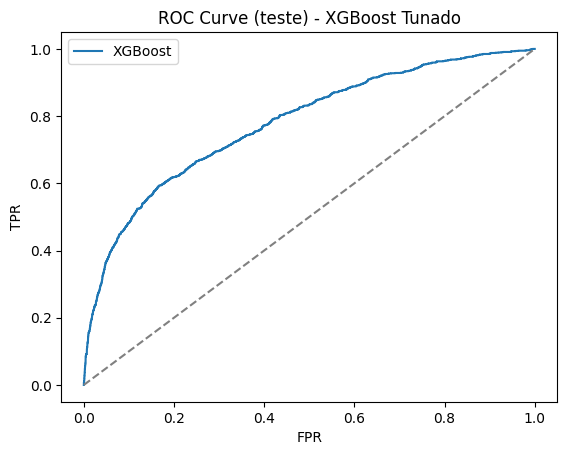

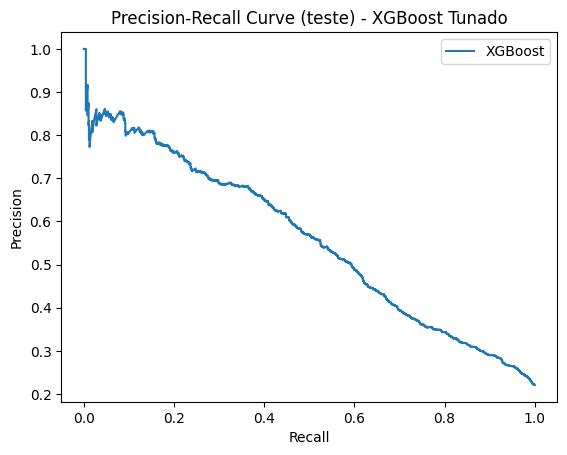

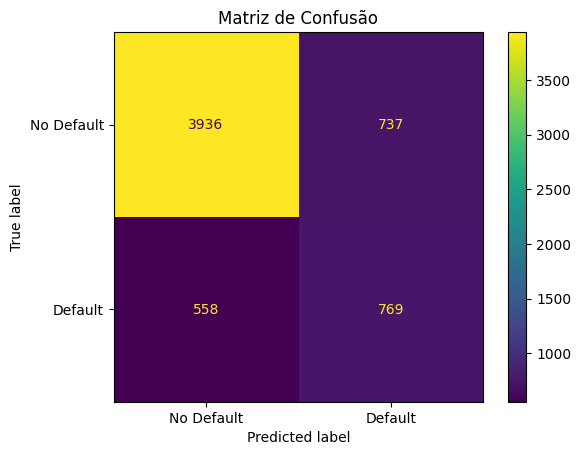


Limitações:
- Possível drift temporal: dados históricos podem mudar.
- XGBoost foi o modelo escolhido por melhor equilíbrio entre ROC-AUC e PR-AUC.


In [13]:
best_model = search_xgb.best_estimator_
print("Modelo final selecionado:", type(best_model).__name__)


best_model.fit(X_train, y_train)
y_proba_test = best_model.predict_proba(X_test)[:,1]
y_pred_test  = (y_proba_test >= 0.5).astype(int)


metrics = summarize_clf_metrics(y_test.values, y_proba_test, threshold=0.5)
print("\nMétricas @0.5:", metrics)
print("\nRelatório de Classificação @0.5:")
print(classification_report(y_test, y_pred_test))

# Otimização de threshold para F1
from sklearn.metrics import f1_score
ths = np.linspace(0.1, 0.9, 81)  # de 0.1 a 0.9 com passo 0.01
f1s = [f1_score(y_test, (y_proba_test >= t).astype(int)) for t in ths]
best_idx = int(np.argmax(f1s))
best_threshold = ths[best_idx]
print(f"\nMelhor threshold para F1: {best_threshold:.2f} → F1={f1s[best_idx]:.4f}")

# Predições com threshold otimizado
y_pred_opt = (y_proba_test >= best_threshold).astype(int)
print("\nRelatório de Classificação @threshold ótimo:")
print(classification_report(y_test, y_pred_opt))

# Curvas ROC e PR
from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
plt.figure()
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (teste) - XGBoost Tunado")
plt.legend()
plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_proba_test)
plt.figure()
plt.plot(rec, prec, label="XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (teste) - XGBoost Tunado")
plt.legend()
plt.show()

# Matriz de confusão
plot_confusion(y_test, y_pred_opt, labels=("No Default","Default"))

print("\nLimitações:")
print("- Possível drift temporal: dados históricos podem mudar.")
print("- XGBoost foi o modelo escolhido por melhor equilíbrio entre ROC-AUC e PR-AUC.")


**Comentários:**

ROC-AUC - modelo distingue bem - 0,778 - positivos e negativos
Classe 0 (clientes bons) → quase perfeita (95% de recall).

Classe 1 (default) → acerta pouco, pois o recall (37%) está baixo → muitos clientes em risco não são detectados (Falso negativo)


| Métrica                   | Threshold 0.5 | Threshold 0.27 | Observação                          |
| ------------------------- | ------------- | -------------- | ----------------------------------- |
| **Precisão (Classe 1)**   | 0.67          | 0.51           | Caiu → mais falsos positivos        |
| **Recall (Classe 1)**     | 0.37          | 0.58           | Subiu → menos falsos negativos      |
| **F1 (Classe 1)**         | 0.48          | 0.54           | Melhorou equilíbrio                 |
| **Falsos Negativos (FN)** | Alto          | Menor          | Detecta mais inadimplentes          |
| **Falsos Positivos (FP)** | Baixo         | Maior          | Marca mais bons clientes como risco |



## 9. Engenharia de atributos (detalhe)

In [14]:
# razão entre pagamentos e fatura
X_eng = X_train.copy()

# (PAY_AMT1..6) / (BILL_AMT1..6) - quanto pagou x fatura
pay_cols = [c for c in X_eng.columns if c.upper().startswith("PAY_AMT")]
bill_cols = [c for c in X_eng.columns if c.upper().startswith("BILL_AMT")]
for p,b in zip(sorted(pay_cols), sorted(bill_cols)):
    ratio_col = f"RATIO_{p}_to_{b}"
    X_eng[ratio_col] = (X_eng[p].replace(0, np.nan)) / (X_eng[b].replace(0, np.nan))

display(X_eng.filter(like="RATIO_").describe().T.head(10))


,count,mean,std,min,25%,50%,75%,max
RATIO_PAY_AMT1_to_BILL_AMT1,19392.0,-3.294482,287.038592,-35436.000000,0.043444,0.078145,0.376401,11453.666667
RATIO_PAY_AMT2_to_BILL_AMT2,19187.0,-2.602098,124.109228,-10259.500000,0.042150,0.074021,0.361179,4444.333333
RATIO_PAY_AMT3_to_BILL_AMT3,18711.0,-8.406220,750.834057,-82150.000000,0.036241,0.058964,0.321471,6333.333333
RATIO_PAY_AMT4_to_BILL_AMT4,18295.0,-2.022764,184.256485,-17266.666667,0.035700,0.051784,0.283672,8891.357143
RATIO_PAY_AMT5_to_BILL_AMT5,18017.0,-1.281750,81.813708,-7483.947368,0.037258,0.055981,0.353294,1308.471338
RATIO_PAY_AMT6_to_BILL_AMT6,17661.0,-0.573567,98.629530,-11349.571429,0.037225,0.056344,0.409914,2643.330000


A criação das variáveis RATIO_PAY_AMT*_to_BILL_AMT* permitiu analisar a proporção entre o valor pago (PAY_AMT) e o valor da fatura mensal correspondente (BILL_AMT). Essa abordagem normaliza os pagamentos em relação ao tamanho da dívida.

O alto std (desvio padrão) mostra a heterogeneidade do comportamento financeiro.
Medianas (50%) reforçam a ideia que clientes não pagam a fatura de forma integral. O comportamento típico é pagar parte da fatura e não de forma integral.
Coluna "Max" - clientes que adiantaram faturas ou correção de períodos anteriores.

## 10. Observações importantes
- Falsos Positivos - classificar como inadimplente quem é bom pagador. Pode ocasionar na perda de um bom cliente
- Falso Negativo - classificar como bom pagador um cliente inadimplente. Prejuízo para a organização.
- Base aleatório porém com efeitos alheios aos indivíduos (crises economicas, catastrofes naturais, etc.). Tal fato pode gerar resultados diferentes se a base for coletada em outro momento.


### 11. Salvando artefatos (modelos e pipeline)

In [15]:
import joblib, os
out_dir = "artifacts"
os.makedirs(out_dir, exist_ok=True)
joblib.dump(best_model, os.path.join(out_dir, "best_model.joblib"))
print("Salvo em:", os.path.join(out_dir, "best_model.joblib"))


Salvo em: artifacts/best_model.joblib
